In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)


df = pd.read_csv("mushrooms.csv")

print("Shape:", df.shape)
df.head()

for col in df.columns:
    if (df[col] == '?').any():
        print(f"Column '{col}' has {(df[col]=='?').sum()} '?' entries")

Shape: (8124, 23)
Column 'stalk-root' has 2480 '?' entries


saME PRE PROCESSING AS BEFORE


In [2]:
encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()

X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8124, 22)
y shape: (8124,)


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean (~0):", X_train_scaled.mean().round(3))
print("Scaled training data std (~1):", X_train_scaled.std().round(3))

Train shape: (6499, 22)
Test shape: (1625, 22)
Scaled training data mean (~0): 0.0
Scaled training data std (~1): 0.977


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

iteration_values = list(range(1000, 100001, 5000))
print("Number of iteration values to test:", len(iteration_values))
print(iteration_values)

Number of iteration values to test: 20
[1000, 6000, 11000, 16000, 21000, 26000, 31000, 36000, 41000, 46000, 51000, 56000, 61000, 66000, 71000, 76000, 81000, 86000, 91000, 96000]


In [8]:
train_f1_scores = []
test_f1_scores = []

for n_iter in iteration_values:
    model = LogisticRegression(max_iter=n_iter, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

print("Done training for all iteration values")

Done training for all iteration values


In [9]:
results_df = pd.DataFrame({
    'Max_Iterations': iteration_values,
    'Train_F1': train_f1_scores,
    'Test_F1': test_f1_scores
})

results_df

best_row = results_df.loc[results_df['Test_F1'].idxmax()]
print("Best max_iter by test F1-score:", int(best_row['Max_Iterations']))
print("Test F1 at that value:", round(best_row['Test_F1'], 4))

Best max_iter by test F1-score: 1000
Test F1 at that value: 0.961


as we can we see 1000 is most likey where it plateus

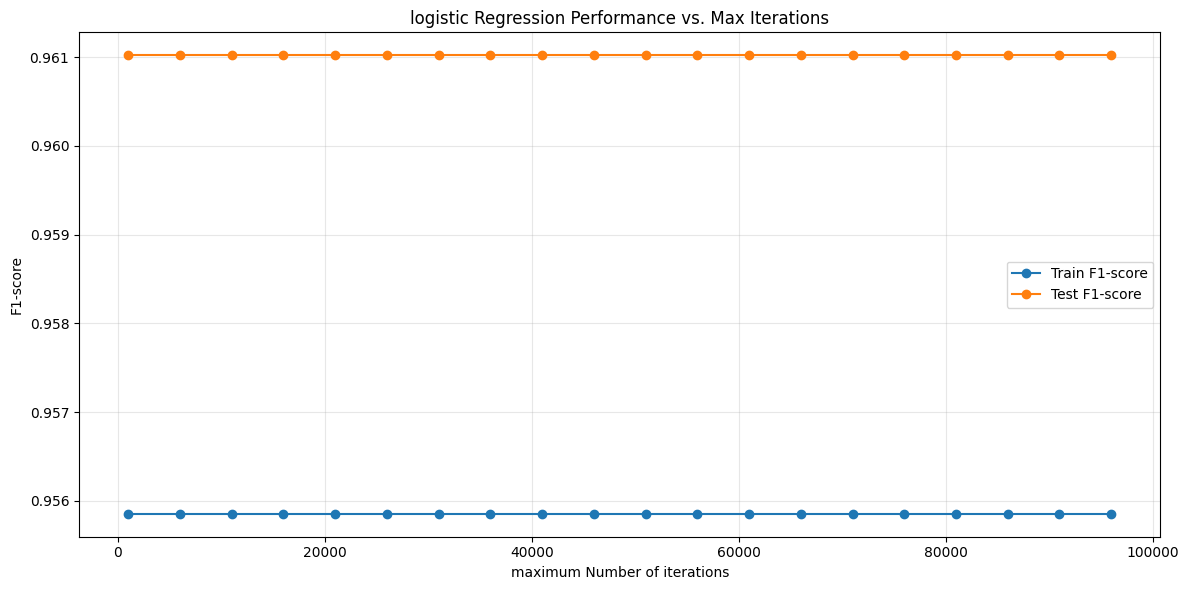

In [13]:

plt.figure(figsize=(12, 6))
plt.plot(results_df['Max_Iterations'], results_df['Train_F1'], marker='o', label='Train F1-score')
plt.plot(results_df['Max_Iterations'], results_df['Test_F1'], marker='o', label='Test F1-score')

plt.xlabel('maximum Number of iterations')
plt.ylabel('F1-score')
plt.title('logistic Regression Performance vs. Max Iterations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

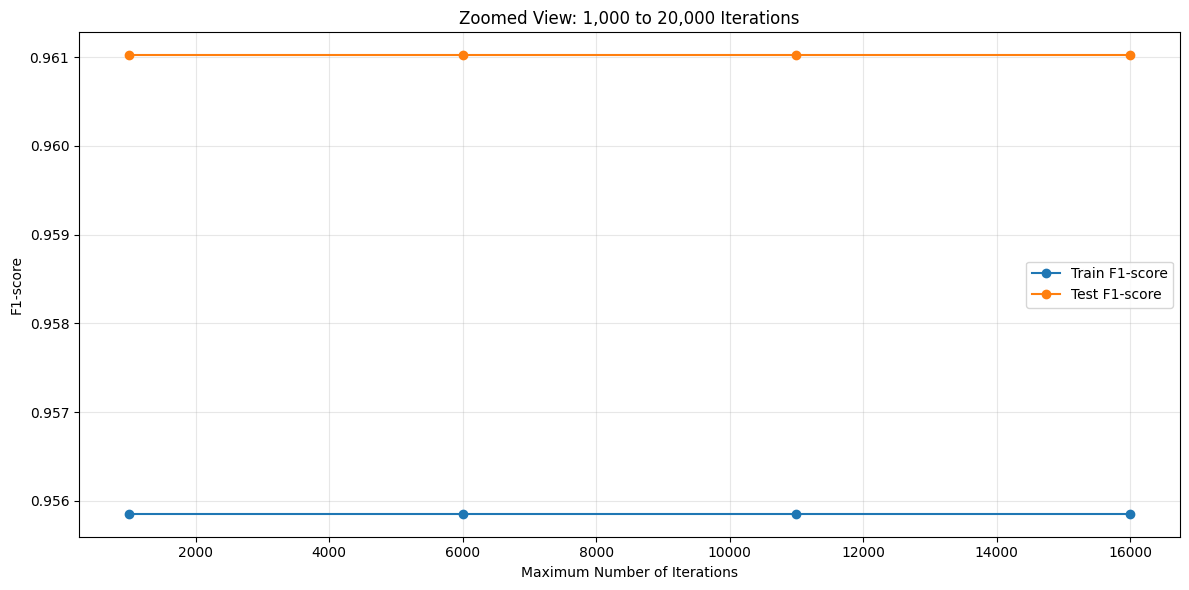

In [11]:
plt.figure(figsize=(12, 6))
zoom = results_df[results_df['Max_Iterations'] <= 20000]

plt.plot(zoom['Max_Iterations'], zoom['Train_F1'], marker='o', label='Train F1-score')
plt.plot(zoom['Max_Iterations'], zoom['Test_F1'], marker='o', label='Test F1-score')

plt.xlabel('Maximum Number of Iterations')
plt.ylabel('F1-score')
plt.title('Zoomed View: 1,000 to 20,000 Iterations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
results_df['F1_Change'] = results_df['Test_F1'].diff()

print("Change in Test F1 between consecutive iteration values:")
print(results_df[['Max_Iterations', 'Test_F1', 'F1_Change']])

# Find the first point where the change becomes negligible (e.g., < 0.0005)
plateau_point = results_df[results_df['F1_Change'].abs() < 0.0005]
if not plateau_point.empty:
    print("\nFirst iteration value where improvement becomes negligible:")
    print(plateau_point.iloc[0])

Change in Test F1 between consecutive iteration values:
    Max_Iterations   Test_F1  F1_Change
0             1000  0.961022        NaN
1             6000  0.961022        0.0
2            11000  0.961022        0.0
3            16000  0.961022        0.0
4            21000  0.961022        0.0
5            26000  0.961022        0.0
6            31000  0.961022        0.0
7            36000  0.961022        0.0
8            41000  0.961022        0.0
9            46000  0.961022        0.0
10           51000  0.961022        0.0
11           56000  0.961022        0.0
12           61000  0.961022        0.0
13           66000  0.961022        0.0
14           71000  0.961022        0.0
15           76000  0.961022        0.0
16           81000  0.961022        0.0
17           86000  0.961022        0.0
18           91000  0.961022        0.0
19           96000  0.961022        0.0

First iteration value where improvement becomes negligible:
Max_Iterations    6000.000000
Train_F1     

F1-score remained completely flat at 0.9610 (test) and 0.9559 (train) across the entire range from 1,000 to 100,000 iterations, with zero change between any consecutive values tested.

This shows the logistic regression solver (lbfgs) fully converges in well under 1,000 iterations, reaching its optimal solution almost immediately.

There is no meaningful "point of diminishing returns' within the tested range, performance was already maximized at the smallest iteration count, not somewhere in the middle.

Since additional iterations produced no improvement, any max_iter value beyond the low thousands represents wasted computation with no benefit to classification performance

The best practical choice is the smallest iteration budget that reliably converges (ex: around 1,000), as it achieves identical performance to 100,000 iterations at a fraction of the computational cost.

